# E66 · Bayesian online experiments: A/B tests at scale, peeking, the winner's curse and bandits

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: the **Upworthy Research Archive** (Matias, Munger, Aubin Le Quere & Ebersole 2021, *Scientific Data* 8:195; OSF project jd64p, CC BY 4.0), exploratory sample: 4,873 headline A/B tests run by the news site Upworthy in 2013-2015, 22,666 "packages" (headline + image variants) with impressions and clicks each |
| **You will learn** | One A/B/n test with **Beta-Binomial** posteriors: P(best), **expected loss** and the value of information, next to a p-value · why **peeking** at a running test ("stop when p < 0.05") inflates false positives, why a Bayesian "P(B > A) > 97.5%" rule does not escape it, and what **optional stopping** does and does not break (calibration vs error control) · a **hierarchical model over 1,000 real tests** to learn the realistic distribution of headline effects: Normal vs **Student-t** effects, a centred/non-centred choice that flips for the t, posterior predictive checks of the tails · the **winner's curse** and a **split-half replication** on real data that checks the shrinkage · the population as the **prior for a new test** · **expected-loss stopping** · **Thompson sampling** vs fixed split vs epsilon-greedy vs explore-then-commit: regret and the cost of learning · a **decision**: how long to test a headline |

## The setting

Upworthy was a viral-news site that, for every story, wrote several candidate headlines (and
sometimes several images) and showed them at random to visitors on its home page and in
boxes on other pages. The package with the most clicks per impression (the **click-through
rate**, CTR) became the headline everyone saw afterwards. Between 2013 and 2015 it ran
tens of thousands of such tests; the archive (Matias et al. 2021) releases them, split into an
exploratory sample, a confirmatory sample and a holdout, and asks researchers to explore on the
first. We use the exploratory sample.

The archive only has final totals per package (impressions and clicks), not the order in which
they arrived. So wherever we need a test *in progress* (peeking, stopping rules, bandits) we
**simulate** it, with CTRs and effect sizes taken from the archive and the model fitted to it.
Every simulated result is labelled as such.

| part | question | tool |
|---|---|---|
| A | Which headline won this one test, and how sure are we? | Beta-Binomial, P(best), expected loss |
| B | How big are headline effects, really? | hierarchical model over 1,000 tests, split-half replication |
| C | Can I look at the test while it runs? | simulated sequential tests: p-values, posterior probabilities, expected loss |
| D | Should I test at all, or adapt as I go? How long? | Thompson sampling and friends, preposterior analysis |

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from IPython.display import display
from scipy import special, stats

from pymc_challenges import data

RANDOM_SEED = 66
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
ARM_COLS = [BLUE, ORANGE, AQUA, PURPLE]
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## The data

In [2]:
data.describe("upworthy_exploratory")
d = data.load("upworthy_exploratory")
d["ctr"] = d["clicks"] / d["impressions"]
tests = d.groupby("test_id", sort=False).agg(
    K=("arm", "size"), impressions=("impressions", "sum"), clicks=("clicks", "sum"))
tests["ctr"] = tests["clicks"] / tests["impressions"]
print(f"{len(tests):,} tests, {len(d):,} arms; arms per test: median {tests.K.median():.0f} "
      f"(range {tests.K.min()}-{tests.K.max()})")
print(f"impressions per arm: median {d.impressions.median():,.0f}; per test: median "
      f"{tests.impressions.median():,.0f}")
print(f"test CTR: median {100 * tests.ctr.median():.2f}%, 5-95% "
      f"{100 * tests.ctr.quantile(0.05):.2f}-{100 * tests.ctr.quantile(0.95):.2f}%")

upworthy_exploratory: Exploratory sample of Upworthy's headline A/B tests, Jan 2013 - Apr 2015: 4,873 tests, 22,666 packages (arms; 2-14 per test, mostly 4-6), one row per package: test_id (clickability_test_id), test_created (date of the test's first package), test_week (YYYYWW), arm (0.. within test, by creation time), content_id (arms of one test with the same id are identical in headline, image, excerpt, lede, share text and square image: natural A/A arms), headline, eyecatcher_id (image), impressions, clicks, significance (Upworthy's dashboard number), first_place, winner (editor's declared winner).
  source: Matias, Munger, Aubin Le Quere & Ebersole (2021), The Upworthy Research Archive, a time series of 32,487 experiments in U.S. media, Scientific Data 8:195 (doi:10.1038/s41597-021-00934-7); OSF project jd64p (CC BY 4.0), file upworthy-archive-exploratory-packages-03.12.2020.csv (the URL). TRIMMED: kept the columns below, dropped excerpt/lede/share text/image URL/slug, added arm

Clicks are rare (about 1 in 80 impressions) and each arm gets a few thousand impressions, so
a typical arm has 40-50 clicks. Binomial noise on 45 clicks is about $\pm 15\%$ of the CTR, which
is the same size as many of the differences a headline test hopes to find.

**A free A/A check.** In 51 tests, two or more arms are *identical* in every creative field
(headline, image, excerpt, lede, share text). These are natural A/A tests: their CTRs should differ
by binomial noise only. If the randomisation or the counting added extra variation, the
standardised differences would be wider than a standard normal.

In [3]:
aa_rows = []
for _, grp in d.groupby(["test_id", "content_id"]):
    if len(grp) > 1:
        n2, k2 = grp["impressions"].to_numpy()[:2], grp["clicks"].to_numpy()[:2]
        pool = k2.sum() / n2.sum()
        aa_rows.append((k2[0] / n2[0] - k2[1] / n2[1]) / np.sqrt(pool * (1 - pool) * (1 / n2).sum()))
z_aa = np.array(aa_rows)
print(f"{len(z_aa)} identical pairs: sd of z = {z_aa.std():.2f} (1 if pure binomial noise; "
      f"a chi-square 90% band for n=51 is {np.sqrt(stats.chi2.ppf([0.05, 0.95], 51) / 51).round(2)})")
print(f"|z| > 1.96 in {np.mean(np.abs(z_aa) > 1.96):.0%} of pairs (5% expected)")

51 identical pairs: sd of z = 1.06 (1 if pure binomial noise; a chi-square 90% band for n=51 is [0.84 1.16])
|z| > 1.96 in 4% of pairs (5% expected)


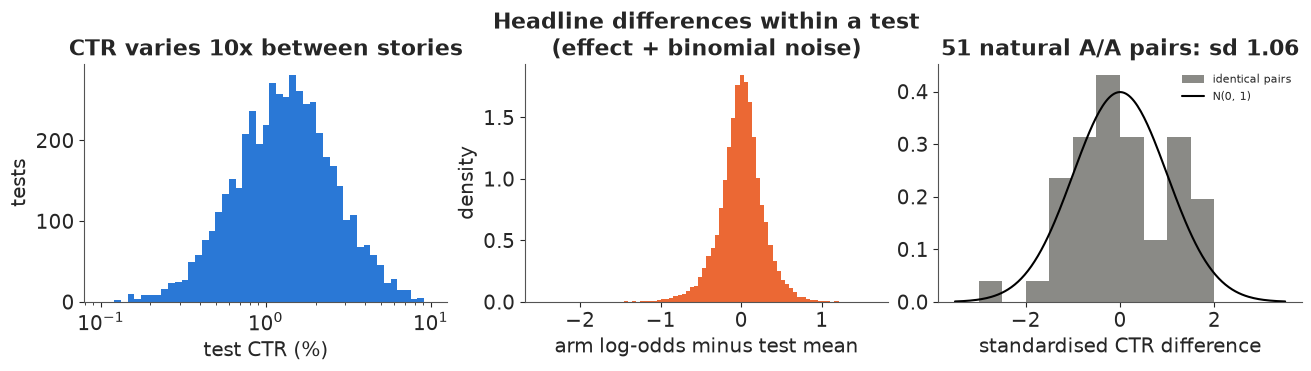

In [4]:
e_all = np.log(d.clicks + 0.5) - np.log(d.impressions - d.clicks + 0.5)
e_all = e_all - e_all.groupby(d.test_id).transform("mean")  # arm logit CTR minus its test's mean
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(100 * tests.ctr, bins=np.geomspace(0.1, 10, 50), color=BLUE)
axes[0].set(xscale="log", xlabel="test CTR (%)", ylabel="tests", title="CTR varies 10x between stories")
axes[1].hist(e_all, bins=80, color=ORANGE, density=True)
axes[1].set(xlabel="arm log-odds minus test mean", ylabel="density",
            title="Headline differences within a test\n(effect + binomial noise)")
xs = np.linspace(-3.5, 3.5, 200)
axes[2].hist(z_aa, bins=np.linspace(-3.5, 3.5, 15), density=True, color=GREY, label="identical pairs")
axes[2].plot(xs, stats.norm.pdf(xs), color="k", label="N(0, 1)")
axes[2].set(xlabel="standardised CTR difference", title=f"51 natural A/A pairs: sd {z_aa.std():.2f}")
axes[2].legend(fontsize=8);

Three things to take forward. Baseline CTRs differ by an order of magnitude between stories, so
effects should be modelled *within* a test, relative to that test's own level. Within tests, arms
differ by a lot: a spread of about $\pm 0.3$ on the log-odds scale, part real effect and part
noise. The natural A/A pairs look like pure binomial noise (sd close to 1, well inside the
chi-square band), which supports a plain binomial likelihood with no extra noise term. Fifty-one
pairs is not many, so this check can only rule out large departures.

---
# Part A · One test

## A1 · Four headlines for one story

A November 2014 test with four headlines for the same video and the same image:

In [5]:
TEST_A = "5459915f288e407b74000032"
ta = d[d.test_id == TEST_A].reset_index(drop=True)
display(ta[["arm", "headline", "impressions", "clicks", "ctr", "significance", "winner"]]
        .assign(ctr=lambda x: (100 * x.ctr).round(2)).rename(columns={"ctr": "CTR (%)"}))

,arm,headline,impressions,clicks,CTR (%),significance,winner
0,0,Watching This Kid Pretend To Be President Obam...,3725,73,1.96,10.5,False
1,1,Watching This Kid Pretend To Be Obama Is Funny...,3735,58,1.55,0.4,False
2,2,"Yeah, Watching This Little Kid Pretend To Be O...",3668,62,1.69,1.3,False
3,3,A Kid Pretends To Be Obama — It's Hilarious. T...,3694,93,2.52,100.0,True


Upworthy's dashboard showed a "significance" of 100 for arm 3 and the editor declared it the
winner. What does a standard analysis say?

In [6]:
nA, kA = ta["impressions"].to_numpy(), ta["clicks"].to_numpy()
chi2_p = stats.chi2_contingency(np.c_[kA, nA - kA])[1]
# the obvious follow-up: winner (arm 3) vs runner-up (arm 0), two-proportion z-test
pool = (kA[3] + kA[0]) / (nA[3] + nA[0])
z30 = (kA[3] / nA[3] - kA[0] / nA[0]) / np.sqrt(pool * (1 - pool) * (1 / nA[3] + 1 / nA[0]))
print(f"chi-square test of 'all four equal': p = {chi2_p:.3f}")
print(f"arm 3 vs runner-up arm 0: z = {z30:.2f}, two-sided p = {2 * stats.norm.sf(abs(z30)):.3f}")

chi-square test of 'all four equal': p = 0.014
arm 3 vs runner-up arm 0: z = 1.62, two-sided p = 0.104


A p-value answers "how surprising would data like these be if all headlines were equal?". The
editor's question is different: **which headline should I run, and what does it cost me if I
pick wrong?** A Bayesian analysis answers that directly.

## A2 · Beta-Binomial posteriors, P(best) and expected loss

Give each arm's CTR $p_k$ a flat Beta(1, 1) prior. With $k$ clicks out of $n$ impressions the
posterior is Beta$(1 + k, 1 + n - k)$ - no sampler needed. From draws of the four posteriors we
get:

* **P(best)**: the share of draws in which arm $k$ has the highest CTR;
* **expected loss** of choosing arm $k$: $E[\max_j p_j - p_k]$, the clicks we expect to give up
  per impression by committing to $k$, in clicks per 1,000 impressions. The expected loss of the
  best choice is also the **expected value of perfect information** (EVPI): the most that any
  further testing could gain per future impression.

The flat prior deserves one comment: it says a 60% CTR is as plausible as 1%, which is absurd.
It barely matters for each arm's *level* here (3,700 impressions dominate it) but, as part B
shows, it matters a great deal for the *differences*.

In [7]:
def beta_draws(k, n, size, a0=1.0, b0=1.0, seed=RANDOM_SEED):
    return np.random.default_rng(seed).beta(a0 + k, b0 + n - k, size=(size, len(k)))


def decision_table(p_draws, labels):
    best = p_draws.max(axis=1, keepdims=True)
    return pd.DataFrame({
        "CTR (%)": 100 * p_draws.mean(axis=0),
        "P(best)": np.bincount(p_draws.argmax(axis=1), minlength=p_draws.shape[1]) / len(p_draws),
        "expected loss (clicks / 1000)": 1000 * (best - p_draws).mean(axis=0),
    }, index=labels).round(3)


pA_flat = beta_draws(kA, nA, 40_000)
tab_flat = decision_table(pA_flat, [f"arm {k}" for k in range(4)])
tab_flat

,CTR (%),P(best),expected loss (clicks / 1000)
arm 0,1.987,0.053,5.644
arm 1,1.579,0.001,9.723
arm 2,1.718,0.005,8.334
arm 3,2.543,0.941,0.085


arm 3's lift over the best other arm: median +25%, 90% interval -1% to +58%


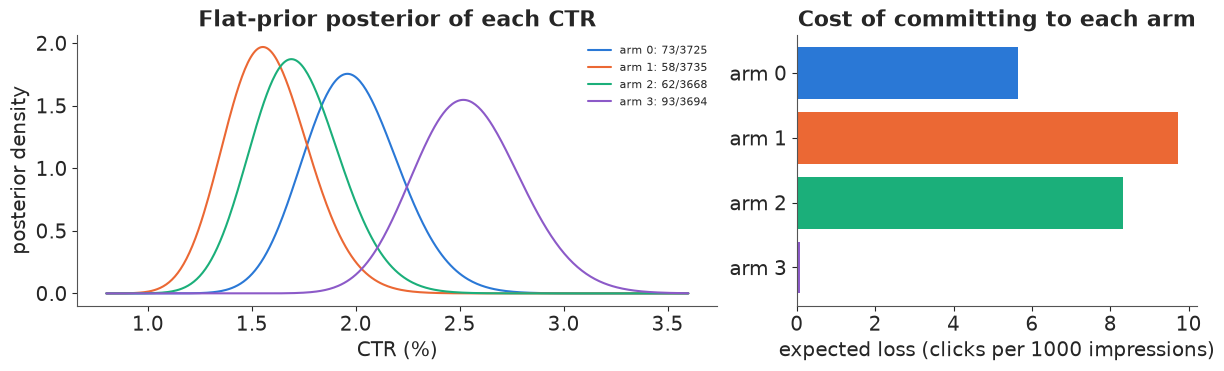

In [8]:
lift_flat = pA_flat[:, 3] / pA_flat[:, [0, 1, 2]].max(axis=1) - 1
print(f"arm 3's lift over the best other arm: median {np.median(lift_flat):+.0%}, "
      f"90% interval {np.quantile(lift_flat, 0.05):+.0%} to {np.quantile(lift_flat, 0.95):+.0%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), width_ratios=[1.6, 1])
grid = np.linspace(0.008, 0.036, 400)
for k in range(4):
    axes[0].plot(100 * grid, stats.beta.pdf(grid, 1 + kA[k], 1 + nA[k] - kA[k]) / 100,
                 color=ARM_COLS[k], label=f"arm {k}: {kA[k]}/{nA[k]}")
axes[0].set(xlabel="CTR (%)", ylabel="posterior density", title="Flat-prior posterior of each CTR")
axes[0].legend(fontsize=8)
axes[1].barh(np.arange(4), tab_flat["expected loss (clicks / 1000)"], color=ARM_COLS)
axes[1].set(yticks=np.arange(4), yticklabels=[f"arm {k}" for k in range(4)],
            xlabel="expected loss (clicks per 1000 impressions)", title="Cost of committing to each arm")
axes[1].invert_yaxis();

With flat priors, arm 3 is best with probability about 0.94 and is estimated to beat the best
alternative by roughly 25% (the 90% interval just touches zero). The p-values disagree with each
other: "all four equal" is rejected (p = 0.014), but arm 3 against the runner-up is not (p = 0.10).
The expected loss has no such ambiguity: committing to arm 3 costs, in expectation, 0.085 clicks
per 1,000 impressions; committing to any other arm costs 6-10. That number is the natural
**stopping rule**: stop when the expected loss of the leader falls below what you are willing to
give up (a *threshold of caring*, say 0.1 clicks per 1,000 at a CTR of about 2%, i.e. 0.5% of the
CTR), not when a p-value crosses 0.05. With that threshold this test would stop and ship arm 3.
Multiplying the EVPI by the traffic still to come gives the most that more testing could be worth:
0.085 per 1,000 over another 100,000 impressions is under 10 clicks.

Two warnings before we trust any of this. First, arm 3's 25% lift was picked *because it was
the largest of four noisy estimates*: the winner's curse says it is probably too big. Second, the
flat prior treats a 25% lift as no more surprising than a 1% one. Both are questions about **what
headline effects usually look like**, and the archive can answer them.

---
# Part B · What do headline effects really look like? A hierarchical model over 1,000 tests

## B1 · The model

For arm $k$ of test $j$ with $n_{jk}$ impressions and $y_{jk}$ clicks:

$$y_{jk} \sim \text{Binomial}(n_{jk}, \operatorname{logit}^{-1}(a_j + \delta_{jk})), \qquad
  \delta_{jk} = r_{jk} - \bar r_j, \qquad r_{jk} \sim \text{Student-}t(\nu, 0, \tau).$$

$a_j$ is the test's average log-odds (each test has ~15,000 impressions, so a separate weakly
informative Normal(-4.2, 1.5) per test is enough; no pooling needed). The arm effects are
centred within their test, so $\delta_{jk}$ is "how much better than this test's average arm",
and every contrast between two arms is $r_{jk} - r_{jl}$, unaffected by the centring. The
centring also removes a ridge between $a_j$ and the mean of the effects that otherwise slows
the sampler. The question is the **distribution of effects**: its scale $\tau$ and its tail
weight $\nu$. A Normal version ($\nu \to \infty$) is the standard assumption; the $t$ lets most
headlines be close and a few very different. Priors: $\tau \sim$ HalfNormal(0.3) (effects of
up to about $\pm 60\%$ in odds are plausible), $\nu \sim$ Gamma(2, 0.1) (mean 20, so the Normal
is not excluded).

To keep the notebook fast we fit a random sample of **1,000 tests** (about 4,650 arms), leaving out
the part-A test so that it can play the role of a new test later.

In [9]:
rng_sub = np.random.default_rng(1)
sub_ids = rng_sub.choice(tests.index[tests.index != TEST_A].to_numpy(), 1000, replace=False)
s = d[d.test_id.isin(sub_ids)].reset_index(drop=True)
tidx, _ = pd.factorize(s["test_id"])
J, Kj = tidx.max() + 1, np.bincount(tidx)
n_s, y_s = s["impressions"].to_numpy(), s["clicks"].to_numpy()
coords_b = {"test": np.arange(J), "arm": np.arange(len(s))}
print(f"{J} tests, {len(s)} arms, {n_s.sum() / 1e6:.1f} M impressions, {y_s.sum():,} clicks")


def build_pop(n, y, effect="t", param="centred"):
    """Hierarchical headline-effect model; effect 'normal' or 't', param 'centred'/'noncentred'."""
    with pm.Model(coords=coords_b) as m:
        a = pm.Normal("a", -4.2, 1.5, dims="test")
        tau = pm.HalfNormal("tau", 0.3)
        nu = pm.Gamma("nu", 2.0, 0.1) if effect == "t" else None
        if param == "centred":
            raw = (pm.StudentT("r", nu=nu, mu=0.0, sigma=tau, dims="arm") if effect == "t"
                   else pm.Normal("r", 0.0, tau, dims="arm"))
        else:
            z = (pm.StudentT("z", nu=nu, mu=0.0, sigma=1.0, dims="arm") if effect == "t"
                 else pm.Normal("z", 0.0, 1.0, dims="arm"))
            raw = tau * z
        test_mean = pt.inc_subtensor(pt.zeros(J)[tidx], raw) / Kj   # mean of raw effects per test
        delta = pm.Deterministic("delta", raw - test_mean[tidx], dims="arm")
        pm.Binomial("clicks", n=n, logit_p=a[tidx] + delta, observed=y, dims="arm")
    return m


def emp_dev(n, y):
    """Empirical arm log-odds minus the test's mean (0.5 added to avoid log 0)."""
    lo = np.log(y + 0.5) - np.log(n - y + 0.5)
    return lo - (np.bincount(tidx, lo) / Kj)[tidx]


e_obs = emp_dev(n_s, y_s)

1000 tests, 4634 arms, 16.5 M impressions, 263,075 clicks


## B2 · Prior predictive check

Before fitting: do the priors produce data that look like headline tests? We compare two
statistics of simulated data with the observed ones: each arm's CTR, and each arm's deviation
from its test's mean on the log-odds scale (the quantity in the middle panel of the first figure).

prior predictive: sd of within-test deviation 0.37 (observed 0.28); share of arms with |dev| > 1: 0.022 (observed 0.005)


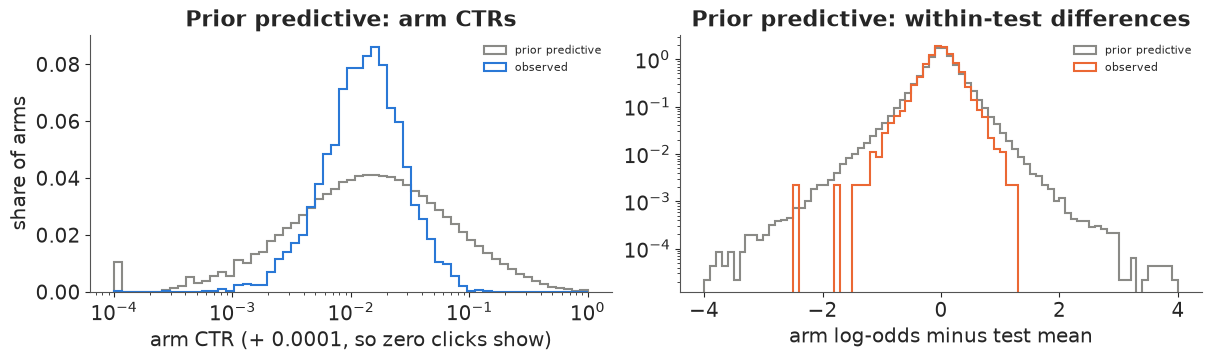

In [10]:
with build_pop(n_s, y_s, "t", "centred"):
    prior_b = pm.sample_prior_predictive(200, random_seed=RANDOM_SEED)
y_prior = prior_b.prior_predictive["clicks"].values.reshape(-1, len(s))
e_prior = np.array([emp_dev(n_s, yy) for yy in y_prior[:100]])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
bins = np.geomspace(1e-4, 1, 60)
ctr_prior = (y_prior / n_s).ravel()
axes[0].hist(ctr_prior + 1e-4, bins=bins, weights=np.full(ctr_prior.size, 1 / ctr_prior.size),
             histtype="step", color=GREY, lw=1.5, label="prior predictive")
axes[0].hist(y_s / n_s + 1e-4, bins=bins, weights=np.full(len(s), 1 / len(s)), histtype="step",
             color=BLUE, lw=1.5, label="observed")
axes[0].set(xscale="log", xlabel="arm CTR (+ 0.0001, so zero clicks show)", ylabel="share of arms",
            title="Prior predictive: arm CTRs")
axes[0].legend(fontsize=8)
bins = np.linspace(-4, 4, 81)
axes[1].hist(e_prior.ravel(), bins=bins, density=True, histtype="step", color=GREY, lw=1.5,
             label="prior predictive")
axes[1].hist(e_obs, bins=bins, density=True, histtype="step", color=ORANGE, lw=1.5, label="observed")
axes[1].set(yscale="log", xlabel="arm log-odds minus test mean",
            title="Prior predictive: within-test differences")
axes[1].legend(fontsize=8)
print(f"prior predictive: sd of within-test deviation {e_prior.std():.2f} (observed {e_obs.std():.2f}); "
      f"share of arms with |dev| > 1: {np.mean(np.abs(e_prior) > 1):.3f} (observed "
      f"{np.mean(np.abs(e_obs) > 1):.3f})")

The prior predictive CTRs span from below 0.01% to tens of percent and cover the observed ones,
and the within-test deviations are wider than observed (sd 0.37 vs 0.28), with heavier tails.
The prior allows the data without forcing them. (The small spike at 0.0001 is arms with zero
clicks, shifted so they show on the log axis.)

## B3 · Fitting: Normal effects, and a sampling failure for the $t$

Three fits, all with nutpie defaults: Normal effects with the usual non-centred parameterisation
($r = \tau z$), and $t$ effects both non-centred and centred.

In [11]:
fits_diag, keep = [], {}
for label, effect, param in [("Normal, non-centred", "normal", "noncentred"),
                             ("t, non-centred", "t", "noncentred"),
                             ("t, centred", "t", "centred")]:
    t0 = time.perf_counter()
    with build_pop(n_s, y_s, effect, param) as m_b:
        idt = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    hyp = ["tau"] + (["nu"] if effect == "t" else [])
    sm = az.summary(idt, var_names=hyp, round_to=4)
    rh = az.rhat(idt).to_dataset()
    fits_diag.append({
        "model": label, "seconds": round(time.perf_counter() - t0),
        "divergences": int(idt.sample_stats["diverging"].sum()),
        "tau": f"{sm.loc['tau', 'mean']:.3f} (ESS {sm.loc['tau', 'ess_bulk']:.0f})",
        "nu": f"{sm.loc['nu', 'mean']:.2f} (ESS {sm.loc['nu', 'ess_bulk']:.0f})" if effect == "t" else "-",
        "max r_hat": round(max(float(rh[v].max()) for v in rh.data_vars), 3),
        "min ESS (delta)": int(az.ess(idt, var_names=["delta"]).to_dataset()["delta"].min()),
    })
    if label != "t, non-centred":
        keep[effect] = (m_b, idt)
    else:
        del idt
pd.DataFrame(fits_diag).set_index("model")

,seconds,divergences,tau,nu,max r_hat,min ESS (delta)
model,,,,,,
"Normal, non-centred",19,0,0.223 (ESS 1452),-,1.009,3988
"t, non-centred",19,0,0.144 (ESS 132),2.99 (ESS 140),1.020,651
"t, centred",19,0,0.145 (ESS 351),3.02 (ESS 455),1.013,867


All three fits run without divergences, but the $t$ model's hyperparameters mix much worse in
the non-centred form: $\tau$ and $\nu$ have ESS of about 130-140 and the worst r_hat is 1.02;
the centred version roughly triples their ESS (350-450) in the same time, with the worst r_hat
over all 5,600 parameters at 1.013. The usual rule "non-centre a
hierarchy" assumes the data per group are weak. Here each arm's ~45 clicks pin its effect to
about $\pm 0.15$, the same size as $\tau$ itself, so neither form is ideal, and for the $t$ the
non-centred $z$ carries the heavy tail: a $z$ in the tail must move together with $\nu$. We
keep the centred $t$ and the non-centred Normal (whose ESS is fine).

The estimates themselves are what the question was about:

In [12]:
m_t, idata_t = keep["t"]
m_n, idata_n = keep["normal"]
az.summary(idata_t, var_names=["tau", "nu"], round_to=4)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,0.1447,0.0070,0.1339,0.1559,350.6053,562.2584,1.0049,0.0004,0.0002
nu,3.0248,0.2898,2.6039,3.5261,454.7777,869.0667,1.0045,0.0137,0.0085


In [13]:
tau_d = az.extract(idata_t, var_names=["tau"]).values
nu_d = az.extract(idata_t, var_names=["nu"]).values
tau_n = az.extract(idata_n, var_names=["tau"]).values
print(f"Normal model: tau = {tau_n.mean():.3f}")
print(f"t model:      tau = {tau_d.mean():.3f}, nu = {nu_d.mean():.2f} "
      f"(90% {np.quantile(nu_d, 0.05):.1f}-{np.quantile(nu_d, 0.95):.1f})")

# effect distribution of the difference between two random headlines of one test
rng_pop = np.random.default_rng(7)
pick = rng_pop.integers(0, tau_d.size, 200_000)
d_pop = tau_d[pick] * (rng_pop.standard_t(nu_d[pick]) - rng_pop.standard_t(nu_d[pick]))
d_nrm = tau_n[pick] * np.sqrt(2) * rng_pop.standard_normal(200_000)
rows = []
for name, dd in [("Normal", d_nrm), ("Student-t", d_pop)]:
    rel = np.abs(np.expm1(dd))
    rows.append({"effects": name, "median |lift|": f"{np.median(rel):.0%}",
                 "P(|lift| < 5%)": round(np.mean(rel < 0.05), 2),
                 "P(|lift| > 50%)": round(np.mean(rel > 0.5), 3),
                 "99th pct |lift|": f"{np.quantile(rel, 0.99):.0%}"})
print("Relative CTR difference between two random headlines of the same test:")
display(pd.DataFrame(rows).set_index("effects"))

Normal model: tau = 0.223
t model:      tau = 0.145, nu = 3.02 (90% 2.6-3.5)
Relative CTR difference between two random headlines of the same test:


,median |lift|,P(|lift| < 5%),P(|lift| > 50%),99th pct |lift|
effects,,,,
Normal,21%,0.13,0.113,107%
Student-t,17%,0.16,0.103,151%


The tail index $\nu$ is about 3: headline effects are **heavy-tailed**. Most pairs of headlines
differ by modest amounts, but a few differ enormously. The two models agree on the typical
size of an effect but not on the tails. Which one fits better?

## B4 · Posterior predictive check: the tails decide

,|dev| > 0.25,|dev| > 0.5,|dev| > 0.75,|dev| > 1.0
,,,,
observed,0.28593,0.071429,0.021148,0.004532
Normal (90% ppc),0.281-0.303,0.049-0.061,0.007-0.012,0.001-0.003
Student-t (90% ppc),0.264-0.286,0.053-0.066,0.012-0.018,0.003-0.006


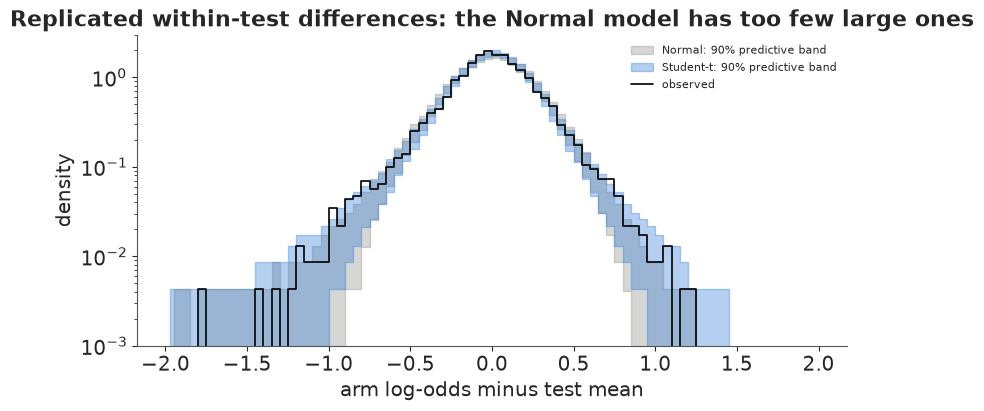

In [14]:
def ppc_dev(model, idt, ndraw=200):
    thin = idt.isel(draw=slice(None, None, 1000 * 4 // ndraw))  # 4 chains x 1000 draws -> ndraw
    with model:
        pp = pm.sample_posterior_predictive(thin, random_seed=RANDOM_SEED, progressbar=False)
    yy = pp.posterior_predictive["clicks"].values.reshape(-1, len(s))[:ndraw]
    return np.array([emp_dev(n_s, row) for row in yy])


e_rep = {"Normal": ppc_dev(m_n, idata_n), "Student-t": ppc_dev(m_t, idata_t)}
thr = [0.25, 0.5, 0.75, 1.0]
rows = [{"": "observed", **{f"|dev| > {t_}": np.mean(np.abs(e_obs) > t_) for t_ in thr}}]
for name, er in e_rep.items():
    frac = np.array([[np.mean(np.abs(row) > t_) for t_ in thr] for row in er])
    lo, hi = np.quantile(frac, [0.05, 0.95], axis=0)
    rows.append({"": f"{name} (90% ppc)", **{f"|dev| > {t_}": f"{a_:.3f}-{b_:.3f}"
                                              for t_, a_, b_ in zip(thr, lo, hi)}})
display(pd.DataFrame(rows).set_index("").round(3))

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(-2, 2, 81)
mid = 0.5 * (bins[1:] + bins[:-1])
for (name, er), col in zip(e_rep.items(), [GREY, BLUE]):
    h = np.array([np.histogram(row, bins, density=True)[0] for row in er])
    ax.fill_between(mid, *np.quantile(h, [0.05, 0.95], axis=0), color=col, alpha=0.35,
                    label=f"{name}: 90% predictive band", step="mid")
ax.step(mid, np.histogram(e_obs, bins, density=True)[0], where="mid", color="k", lw=1.2, label="observed")
ax.set(yscale="log", ylim=(1e-3, 3), xlabel="arm log-odds minus test mean", ylabel="density",
       title="Replicated within-test differences: the Normal model has too few large ones")
ax.legend(fontsize=8);

The Normal model reproduces the centre of the distribution but not the tails: 2.1% of arms lie
more than 0.75 from their test's mean and 0.45% more than 1.0, while the Normal model predicts
0.7-1.2% and 0.1-0.3%. The $t$ model's 90% ranges contain the observed fractions beyond 0.5 and
1.0 and just miss at 0.75 (1.2-1.8% vs 2.1%) and at 0.25, so it is better but not perfect. (We do not use
PSIS-LOO here: every arm has its own effect, so leaving an arm out removes all information about
that effect and the importance weights are unreliable. The split-half check below is a sharper
out-of-sample test of what we need.)

## B5 · The winner's curse, and a real replication

In each test the arm with the highest observed CTR is the "winner". Its observed advantage is
biased upwards: it won partly *because* its noise was favourable. The hierarchical posterior
shrinks every arm's effect towards 0; a heavy-tailed prior shrinks small effects hard and
leaves large, well-measured effects mostly alone.

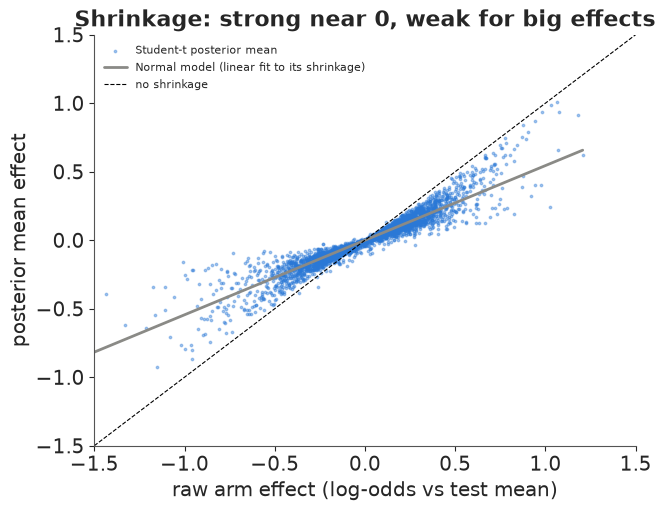

In [15]:
dm_t = idata_t.posterior["delta"].mean(("chain", "draw")).values
dm_n = idata_n.posterior["delta"].mean(("chain", "draw")).values
fig, ax = plt.subplots(figsize=(6.5, 5))
order = np.argsort(e_obs)
ax.scatter(e_obs, dm_t, s=3, color=BLUE, alpha=0.4, label="Student-t posterior mean")
ax.plot(e_obs[order], np.poly1d(np.polyfit(e_obs, dm_n, 1))(e_obs[order]), color=GREY, lw=2,
        label="Normal model (linear fit to its shrinkage)")
ax.plot([-1.5, 1.5], [-1.5, 1.5], color="k", lw=0.8, ls="--", label="no shrinkage")
ax.set(xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), xlabel="raw arm effect (log-odds vs test mean)",
       ylabel="posterior mean effect", title="Shrinkage: strong near 0, weak for big effects")
ax.legend(fontsize=8);

Is the shrinkage right? The archive has no repeated tests, but a binomial count can be split.
If each impression is an independent Bernoulli trial, drawing half of an arm's impressions at
random (a hypergeometric draw of the clicks) gives two **independent** half-samples of the same
arm. We fit both models to half 1 only, pick each test's winner on half 1, and ask half 2
how good the winner really is. Half 2 did not take part in the selection, so its average is an
unbiased estimate of the winners' true effect.

In [16]:
rng_split = np.random.default_rng(11)
n1 = n_s // 2
y1 = rng_split.hypergeometric(y_s, n_s - y_s, n1)
n2, y2 = n_s - n1, y_s - y1
e1, e2 = emp_dev(n1, y1), emp_dev(n2, y2)
win = pd.Series(e1).groupby(tidx).idxmax().to_numpy()  # each test's half-1 winner

split_post = {}
for effect, param in [("normal", "noncentred"), ("t", "centred")]:
    with build_pop(n1, y1, effect, param):
        idt = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    split_post[effect] = idt.posterior["delta"].mean(("chain", "draw")).values
    print(f"half-1 fit ({effect}): divergences {int(idt.sample_stats['diverging'].sum())}, "
          f"max r_hat {max(float(v.max()) for v in az.rhat(idt).to_dataset().data_vars.values()):.3f}")
    del idt

se_rep = e2[win].std() / np.sqrt(J)
res = pd.DataFrame({
    "winner's effect, estimated from half 1": {
        "raw (observed CTR)": e1[win].mean(),
        "Normal hierarchical": split_post["normal"][win].mean(),
        "Student-t hierarchical": split_post["t"][win].mean()},
}).assign(**{"relative to the average arm": lambda x: x.iloc[:, 0].map(lambda v: f"{np.expm1(v):+.0%}")})
res.loc["replication in half 2 (truth, +- 1 se)"] = [e2[win].mean(),
                                                     f"{np.expm1(e2[win].mean()):+.0%} +- {se_rep:.2f}"]
res.round(3)

half-1 fit (normal): divergences 0, max r_hat 1.009


half-1 fit (t): divergences 0, max r_hat 1.014


,"winner's effect, estimated from half 1",relative to the average arm
raw (observed CTR),0.347,+42%
Normal hierarchical,0.166,+18%
Student-t hierarchical,0.161,+17%
"replication in half 2 (truth, +- 1 se)",0.177,+19% +- 0.01


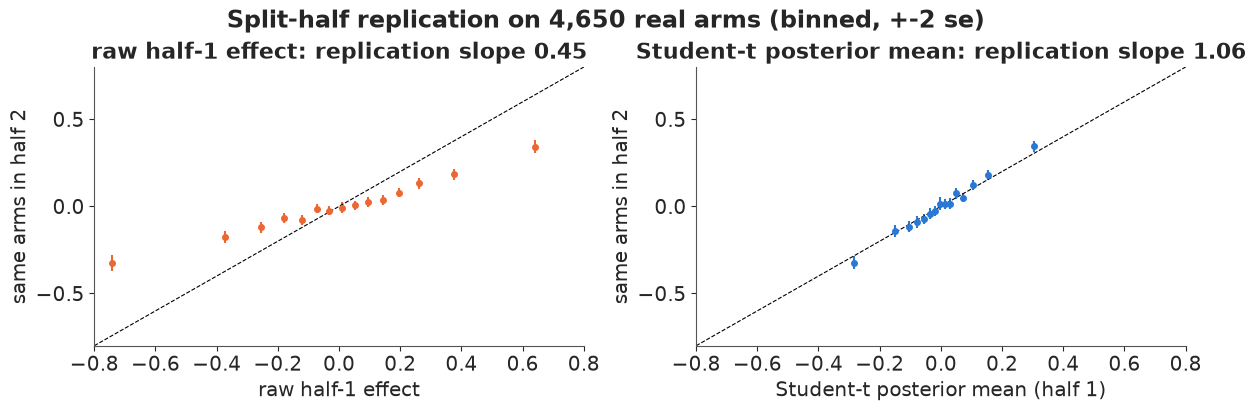

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (lab, est), col in zip(axes, [("raw half-1 effect", e1), ("Student-t posterior mean (half 1)",
                                                                    split_post["t"])], [ORANGE, BLUE]):
    edges = np.quantile(est, np.linspace(0, 1, 16))
    b_ = np.clip(np.digitize(est, edges[1:-1]), 0, 14)
    xm = np.array([est[b_ == i].mean() for i in range(15)])
    ym = np.array([e2[b_ == i].mean() for i in range(15)])
    ys = np.array([e2[b_ == i].std() / np.sqrt((b_ == i).sum()) for i in range(15)])
    ax.errorbar(xm, ym, 2 * ys, fmt="o", color=col, ms=4)
    ax.plot([-0.8, 0.8], [-0.8, 0.8], color="k", lw=0.8, ls="--")
    slope = np.polyfit(est, e2, 1)[0]
    ax.set(xlim=(-0.8, 0.8), ylim=(-0.8, 0.8), xlabel=lab, ylabel="same arms in half 2",
           title=f"{lab.split(' (')[0]}: replication slope {slope:.2f}")
fig.suptitle("Split-half replication on 4,650 real arms (binned, +-2 se)");

This is the winner's curse measured on real data: the winners' raw half-1 advantage is about
twice what the same arms achieve in fresh impressions. Both hierarchical models predict the
replication almost exactly. Across all arms, the raw estimates replicate with a slope of about
0.45 (they are too extreme by a factor of two), the $t$ posterior means with a slope close to 1:
they are **calibrated**. The Normal model does nearly as well on the *average* winner; its
weakness is in the tails (B4), which matter for the large-effect decisions.

## B6 · The population as the prior for a new test

Back to the part-A test, which was not in the fitted sample. Instead of flat priors on each
arm's CTR, we use what 1,000 earlier tests learned about how headlines differ: the Student-t
effect prior with $\tau$ and $\nu$ fixed at their posterior medians (their posterior is narrow,
so plugging them in loses little).

In [18]:
TAU_HAT, NU_HAT = float(np.median(tau_d)), float(np.median(nu_d))
with pm.Model(coords={"arm": np.arange(4)}) as m_new:
    a0 = pm.Normal("a", -4.2, 1.5)
    r0 = pm.StudentT("r", nu=NU_HAT, mu=0.0, sigma=TAU_HAT, dims="arm")
    delta0 = pm.Deterministic("delta", r0 - r0.mean(), dims="arm")
    p0 = pm.Deterministic("p", pm.math.invlogit(a0 + delta0), dims="arm")
    pm.Binomial("clicks", n=nA, p=p0, observed=kA, dims="arm")
    idata_new = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"divergences {int(idata_new.sample_stats['diverging'].sum())}, "
      f"max r_hat {float(az.rhat(idata_new, var_names=['p']).to_dataset()['p'].max()):.3f}")
pA_pop = az.extract(idata_new, var_names=["p"]).values.T
tab_pop = decision_table(pA_pop, [f"arm {k}" for k in range(4)])
lift_pop = pA_pop[:, 3] / pA_pop[:, [0, 1, 2]].max(axis=1) - 1
pd.concat({"flat prior": tab_flat, "population prior": tab_pop}, axis=1)

divergences 0, max r_hat 1.002


flat prior                                       population prior  \
         CTR (%) P(best) expected loss (clicks / 1000)          CTR (%)   
arm 0      1.987   0.053                         5.644            1.937   
arm 1      1.579   0.001                         9.723            1.672   
arm 2      1.718   0.005                         8.334            1.763   
arm 3      2.543   0.941                         0.085            2.351   

                                             
      P(best) expected loss (clicks / 1000)  
arm 0   0.075                         4.264  
arm 1   0.004                         6.906  
arm 2   0.016                         5.999  
arm 3   0.906                         0.125

arm 3 lift over the best other arm: flat +25% (90% -1% to +58%); population +18% (90% -4% to +47%)


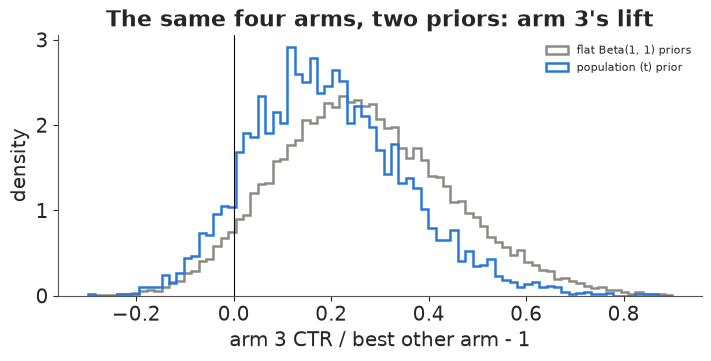

In [19]:
print(f"arm 3 lift over the best other arm: flat {np.median(lift_flat):+.0%} "
      f"(90% {np.quantile(lift_flat, 0.05):+.0%} to {np.quantile(lift_flat, 0.95):+.0%}); "
      f"population {np.median(lift_pop):+.0%} "
      f"(90% {np.quantile(lift_pop, 0.05):+.0%} to {np.quantile(lift_pop, 0.95):+.0%})")
fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.linspace(-0.3, 0.9, 80)
ax.hist(lift_flat, bins, density=True, histtype="step", lw=1.8, color=GREY, label="flat Beta(1, 1) priors")
ax.hist(lift_pop, bins, density=True, histtype="step", lw=1.8, color=BLUE, label="population (t) prior")
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="arm 3 CTR / best other arm - 1", ylabel="density",
       title="The same four arms, two priors: arm 3's lift")
ax.legend(fontsize=8);

Arm 3 is still the most probable winner, but everything moves towards "less sure, smaller":
P(best) drops from 0.94 to about 0.91, the median lift from +25% to +18% (90% interval about -4%
to +47%), and the expected loss of shipping arm 3 rises from 0.085 to about 0.125 clicks per
1,000 impressions - **above** the 0.1 threshold, so under the population prior this test would
keep running a little longer. The +18% is what a forecast of extra clicks from the new headline
should use, and the population prior is the one whose estimates the split-half check just showed
to be calibrated.

---
# Part C · Looking at a running test (simulated tests)

In practice nobody waits: the dashboard updates every few minutes and it is tempting to stop
as soon as it says "significant". The archive has only final totals, so we **simulate**
two-arm tests with realistic numbers: each simulated test takes the CTR of a randomly drawn real
test as its baseline, gets 250 impressions per arm between looks, and runs for at most 20 looks
(5,000 impressions per arm, a bit more than an average Upworthy arm).

With clicks this rare, the pair of click counts carries almost all the information about the
difference through one number: given $m = y_A + y_B$ total clicks on equal traffic, $y_B \sim
\text{Binomial}(m, \operatorname{logit}^{-1}(d))$ where $d$ is the log rate ratio (essentially the
log-odds difference at CTRs near 1%). This lets us compute exact posteriors for 20,000 tests at
every look in NumPy:

* **flat prior**: uniform prior on the click share, so P(B > A) = P(Beta$(1 + y_B, 1 + y_A) > 1/2)$;
* **population prior**: $d$ = difference of two draws from the fitted Student-t effects
  (integrating over the posterior of $\tau$, $\nu$), posterior on a grid.

Decision rules: the frequentist **"p < 0.05"** (two-proportion z-test), and the Bayesian
**"P(B > A) > 0.975 or < 0.025"**, the one-sided analogue of the same 5% error budget.

In [20]:
S_SIM, STEP, LOOKS = 20_000, 250, 20
n_look = STEP * np.arange(1, LOOKS + 1)
base_logit = special.logit(tests["ctr"].to_numpy())
d_grid = np.linspace(-2.5, 2.5, 501)
dg = d_grid[1] - d_grid[0]
prior_pop = np.histogram(d_pop, bins=np.r_[d_grid - dg / 2, d_grid[-1] + dg / 2], density=True)[0]
prior_pop = np.convolve(prior_pop, np.ones(5) / 5, mode="same") + 1e-12  # light smoothing
log_prior_pop = np.log(prior_pop / prior_pop.sum())
log_pi, log_1mpi = -np.logaddexp(0, -d_grid), -np.logaddexp(0, d_grid)


def simulate_tests(d_true, seed):
    """Cumulative clicks of arms A and B at each look; d_true is the log rate ratio B/A."""
    r = np.random.default_rng(seed)
    base = r.choice(base_logit, len(d_true))
    pa, pb = special.expit(base - d_true / 2), special.expit(base + d_true / 2)
    ya = np.cumsum(r.binomial(STEP, pa[:, None], (len(d_true), LOOKS)), axis=1)
    yb = np.cumsum(r.binomial(STEP, pb[:, None], (len(d_true), LOOKS)), axis=1)
    return ya, yb, pa, pb


def pop_posterior(ya_l, yb_l):
    """Grid posterior of d under the population prior, one row per test."""
    lp = log_prior_pop + yb_l[:, None] * log_pi + ya_l[:, None] * log_1mpi
    w = np.exp(lp - lp.max(axis=1, keepdims=True))
    return w / w.sum(axis=1, keepdims=True)


def run_rules(ya, yb):
    """Per look: z-test p<0.05, and P(B>A) under flat and population priors."""
    na = n_look[None, :]
    pool = (ya + yb) / (2 * na)
    se = np.sqrt(pool * (1 - pool) * 2 / na)
    z = np.where(se > 0, (yb - ya) / na / np.where(se > 0, se, 1), 0.0)
    p_flat = stats.beta.sf(0.5, 1 + yb, 1 + ya)
    p_pop = np.column_stack([pop_posterior(ya[:, l], yb[:, l])[:, d_grid > 0].sum(axis=1)
                             for l in range(LOOKS)])
    return {"p < 0.05": np.abs(z) > 1.96,
            "flat prior: P(B>A) > .975 or < .025": (p_flat > 0.975) | (p_flat < 0.025),
            "population prior: same threshold": (p_pop > 0.975) | (p_pop < 0.025)}, p_flat, p_pop


ya0, yb0, pa0, pb0 = simulate_tests(np.zeros(S_SIM), seed=21)        # A/A: no difference at all
dec_aa, _, _ = run_rules(ya0, yb0)
rows = {k: {"one look at the end": v[:, -1].mean(), "peek at all 20 looks": v.any(axis=1).mean()}
        for k, v in dec_aa.items()}
print("A/A tests (simulated): share declaring a winner")
display(pd.DataFrame(rows).T.round(3))

A/A tests (simulated): share declaring a winner


,one look at the end,peek at all 20 looks
p < 0.05,0.050,0.245
flat prior: P(B>A) > .975 or < .025,0.048,0.222
population prior: same threshold,0.015,0.042


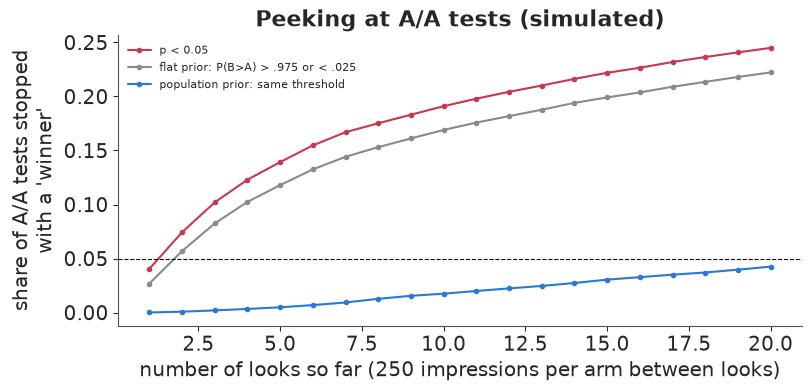

In [21]:
fig, ax = plt.subplots(figsize=(8, 3.8))
for (k, v), col in zip(dec_aa.items(), [RED, GREY, BLUE]):
    ax.plot(np.arange(1, LOOKS + 1), np.maximum.accumulate(v, axis=1).mean(axis=0), "o-", ms=3,
            color=col, label=k)
ax.axhline(0.05, color="k", lw=0.8, ls="--")
ax.set(xlabel="number of looks so far (250 impressions per arm between looks)",
       ylabel="share of A/A tests stopped\nwith a 'winner'", title="Peeking at A/A tests (simulated)")
ax.legend(fontsize=8);

Checking a p-value at every look and stopping at the first "p < 0.05" turns a 5% false-positive
rate into about 25% over 20 looks, and it keeps climbing with more looks. The Bayesian rule with a
flat prior is **no better** (22%): with a flat prior, P(B > A) > 0.975 is numerically almost the
same event as a one-sided p < 0.025, and it inherits the same inflation. The population prior
helps, because it expects most differences to be small and so needs more evidence, but its A/A
"winner" rate still rises from 1.5% at a single look to about 4% with peeking.

This is the honest statement about Bayesian stopping: **the posterior is not affected by the
stopping rule** (the likelihood principle), so a posterior computed after peeking means exactly
what it would mean without peeking. That guarantee is about **calibration** - among all the
tests where you claim "97.5% sure B is better", B is better about 97.5% of the time - **when the
tests come from the population your prior describes**. It is not a guarantee about the error
rate in a world where every difference is exactly zero, which is what the A/A figure measures.
A/A tests are not drawn from our prior (the prior puts no mass exactly at 0), so there the
claim "97.5% sure" is just wrong in the way any claim would be.

Let us check the calibration claim where it applies: tests whose true effect is drawn from the
fitted population (simulated from the model, so this is the ideal case for the population prior).

In [22]:
rng_eff = np.random.default_rng(31)
pick = rng_eff.integers(0, tau_d.size, S_SIM)
d_eff = tau_d[pick] * (rng_eff.standard_t(nu_d[pick]) - rng_eff.standard_t(nu_d[pick]))
print(f"share of effects beyond the +-2.5 grid (clipped): {np.mean(np.abs(d_eff) > 2.5):.4f}")
d_eff = np.clip(d_eff, -2.5, 2.5)
ya1, yb1, pa1, pb1 = simulate_tests(d_eff, seed=32)
dec_eff, pf1, pp1 = run_rules(ya1, yb1)
rows = []
for name, dec, pb in [("flat prior", dec_eff["flat prior: P(B>A) > .975 or < .025"], pf1),
                      ("population prior", dec_eff["population prior: same threshold"], pp1)]:
    for mode in ["fixed horizon (look 20 only)", "peeking (stop at first crossing)"]:
        if mode.startswith("fixed"):
            stop, claimed = np.full(S_SIM, LOOKS - 1), dec[:, -1]
        else:
            claimed = dec.any(axis=1)
            stop = np.where(claimed, dec.argmax(axis=1), LOOKS - 1)
        says_b = pb[np.arange(S_SIM), stop] > 0.5
        correct = says_b == (d_eff > 0)
        rows.append({"prior": name, "rule": mode, "share of tests with a claim": claimed.mean(),
                     "claims that are right": correct[claimed].mean(),
                     "mean impressions per arm": n_look[stop].mean()})
cal = pd.DataFrame(rows).set_index(["prior", "rule"]).round(3)
cal

share of effects beyond the +-2.5 grid (clipped): 0.0009


share of tests with a claim  \
prior            rule                                                            
flat prior       fixed horizon (look 20 only)                            0.299   
                 peeking (stop at first crossing)                        0.452   
population prior fixed horizon (look 20 only)                            0.220   
                 peeking (stop at first crossing)                        0.262   

                                                   claims that are right  \
prior            rule                                                      
flat prior       fixed horizon (look 20 only)                      0.984   
                 peeking (stop at first crossing)                  0.914   
population prior fixed horizon (look 20 only)                      0.993   
                 peeking (stop at first crossing)                  0.983   

                                                   mean impressions per arm  
prior            rule                                                        
flat prior       fixed horizon (look 20 only)                       5000.00  
                 peeking (stop at first crossing)                   3568.95  
population prior fixed horizon (look 20 only)                       5000.00  
                 peeking (stop at first crossing)                   4387.85

With effects drawn from the population, claims made with the population prior are right about
98-99% of the time **with or without peeking** (each claim was made at P > 0.975, so that is what
calibration promises): the posterior probability survives optional stopping, and peeking buys
somewhat earlier decisions. The flat prior's claims are right 98% of the time when it looks
once, but only about 91% of the time when it peeks - below the 97.5% each claim announced -
because a flat prior takes early noisy differences at face value. Calibration is a property of
**prior + model**, not of the word "Bayesian".

## C2 · Stopping on expected loss

A/B tests are not really about claims but about choices, and a wrong choice between two nearly
equal headlines costs almost nothing. The expected-loss rule stops as soon as the leader's
expected loss (under the population prior) is below a **threshold of caring** $\varepsilon$, in
clicks per 1,000 impressions, and picks the leader. With baseline CTR $p_0$, choosing A when the
truth is $d$ costs $p_0 \max(e^{d} - 1, 0)$ per impression (and symmetrically for B).

In [23]:
def expected_loss_rule(ya, yb, pa, pb, eps_list):
    gap = 2 * np.sinh(d_grid / 2)   # (p_B - p_A) / p0 with p_A = p0 e^(-d/2), p_B = p0 e^(d/2)
    loss_a = np.empty((len(ya), LOOKS))
    loss_b = np.empty_like(loss_a)
    for l in range(LOOKS):
        p0 = (ya[:, l] + yb[:, l] + 1) / (2 * n_look[l] + 2)   # pooled CTR so far
        w = pop_posterior(ya[:, l], yb[:, l])
        loss_a[:, l] = 1000 * p0 * (w * np.maximum(gap, 0)).sum(axis=1)
        loss_b[:, l] = 1000 * p0 * (w * np.maximum(-gap, 0)).sum(axis=1)
    true_a = 1000 * np.maximum(pb - pa, 0)   # realised loss of each choice (true CTRs)
    true_b = 1000 * np.maximum(pa - pb, 0)
    out = []
    for eps in eps_list:
        ok = np.minimum(loss_a, loss_b) < eps
        stop = np.where(ok.any(axis=1), ok.argmax(axis=1), LOOKS - 1)
        choose_b = loss_b[np.arange(len(ya)), stop] < loss_a[np.arange(len(ya)), stop]
        realised = np.where(choose_b, true_b, true_a)
        early = ok.any(axis=1)
        out.append({"epsilon (clicks / 1000)": eps,
                    "mean impressions per arm": n_look[stop].mean(),
                    "stopped before the cap": early.mean(),
                    "realised loss, early stops": realised[early].mean(),
                    "realised loss, all tests": realised.mean()})
    return pd.DataFrame(out).set_index("epsilon (clicks / 1000)")


EPS = [0.5, 0.2, 0.1, 0.05, 0.02]
el_eff = expected_loss_rule(ya1, yb1, pa1, pb1, EPS)
el_aa = expected_loss_rule(ya0, yb0, pa0, pb0, EPS)
coin = 1000 * np.abs(pb1 - pa1).mean() / 2
fixed = 1000 * np.where(yb1[:, -1] > ya1[:, -1], np.maximum(pa1 - pb1, 0), np.maximum(pb1 - pa1, 0)).mean()
print(f"for scale (effects from the population): a coin flip between the arms loses {coin:.3f} "
      f"clicks / 1000; picking the arm with more clicks after 5,000 per arm loses {fixed:.3f}.")
display(pd.concat({"effects from the population": el_eff, "A/A tests": el_aa}, axis=1).round(3))

for scale (effects from the population): a coin flip between the arms loses 1.908 clicks / 1000; picking the arm with more clicks after 5,000 per arm loses 0.218.


effects from the population                         \
                           mean impressions per arm stopped before the cap   
epsilon (clicks / 1000)                                                      
0.50                                       1300.488                  0.973   
0.20                                       2873.950                  0.751   
0.10                                       3690.612                  0.532   
0.05                                       4140.938                  0.382   
0.02                                       4449.275                  0.262   

                                                                             \
                        realised loss, early stops realised loss, all tests   
epsilon (clicks / 1000)                                                       
0.50                                         0.379                    0.392   
0.20                                         0.152                    0.238   
0.10                                         0.072                    0.222   
0.05                                         0.033                    0.219   
0.02                                         0.012                    0.219   

                                       A/A tests                         \
                        mean impressions per arm stopped before the cap   
epsilon (clicks / 1000)                                                   
0.50                                    1593.238                  0.941   
0.20                                    3557.150                  0.562   
0.10                                    4430.688                  0.273   
0.05                                    4783.388                  0.118   
0.02                                    4937.350                  0.038   

                                                                             
                        realised loss, early stops realised loss, all tests  
epsilon (clicks / 1000)                                                      
0.50                                           0.0                      0.0  
0.20                                           0.0                      0.0  
0.10                                           0.0                      0.0  
0.05                                           0.0                      0.0  
0.02                                           0.0                      0.0

The threshold trades time for loss, in units a product owner understands. A coin flip loses
about 1.9 clicks per 1,000 impressions; running every test to the 5,000 cap loses 0.22. With
$\varepsilon = 0.5$ the average test stops after about 1,300 impressions per arm and loses 0.39;
with $\varepsilon = 0.2$, three quarters of tests stop early and the loss is within 0.02 of
running to the cap. Among the tests that stop early the realised loss is below the threshold, as
it should be when the prior matches the population (the "all tests" column is higher because
tests that hit the cap were the hard, close ones). From $\varepsilon = 0.1$ down the overall loss
barely moves while more and more tests run to the cap: smaller thresholds only cost time. In A/A tests the rule also stops and picks an arbitrary
arm, which costs exactly nothing: a "false positive" is harmless when the arms are equal. What the
rule gives is not a claim that the chosen arm is better, but a choice whose expected cost is small.

---
# Part D · Adapting while testing: bandits (simulated)

A fixed-split test shows the worse headlines to half or more of the traffic for the whole
test. A **multi-armed bandit** shifts traffic towards arms that look good while it learns.
**Thompson sampling** (TS) does this by showing each arm with the probability that it is the
best, computed from its Beta posterior - so exploration fades exactly as fast as uncertainty.

We simulate 2,000 four-headline tests from the fitted population: each draws a baseline CTR
from the archive and four arm effects from the Student-t population (with $\tau$, $\nu$ from
their posterior). Traffic arrives in batches of 100 impressions for 20,000 impressions (about an
Upworthy test's size), and the policies are:

* **fixed split**: 25% each throughout (the classic A/B/n test);
* **explore-then-commit**: fixed split for the first 1,000 impressions per arm, then all traffic
  to the leader;
* **epsilon-greedy**: 90% to the current leader, 10% spread evenly;
* **Thompson sampling** with flat Beta(1, 1) priors.

**Regret** is the number of clicks lost compared with showing the truly best arm to everyone.

In [24]:
S_B, K_B, BATCH, NB = 2_000, 4, 100, 200
rng_b = np.random.default_rng(41)
pick = rng_b.integers(0, tau_d.size, S_B)
raw_b = tau_d[pick, None] * rng_b.standard_t(nu_d[pick, None], (S_B, K_B))
p_b = special.expit(rng_b.choice(base_logit, S_B)[:, None] + raw_b - raw_b.mean(axis=1, keepdims=True))
p_best = p_b.max(axis=1)


def run_policy(policy, p, nb=NB, batch=BATCH, n_explore=1000, eps=0.1, m_ts=100, seed=0):
    r = np.random.default_rng(seed)
    S, K = p.shape
    clicks, shows = np.zeros((S, K)), np.zeros((S, K))
    regret = np.zeros((S, nb))
    for b in range(nb):
        leader = np.argmax((clicks + 1) / (shows + 2), axis=1)
        if policy == "fixed split" or (policy == "explore-then-commit" and b * batch < n_explore * K):
            alloc = np.full((S, K), 1 / K)
        elif policy == "explore-then-commit":
            alloc = np.eye(K)[leader]
        elif policy == "epsilon-greedy":
            alloc = np.full((S, K), eps / K)
            alloc[np.arange(S), leader] += 1 - eps
        else:  # Thompson sampling: P(arm is best) from m_ts posterior draws per arm
            draw = r.beta(1 + clicks[:, :, None], 1 + shows[:, :, None] - clicks[:, :, None], (S, K, m_ts))
            alloc = np.stack([(draw.argmax(axis=1) == k).mean(axis=1) for k in range(K)], axis=1)
        nk = r.multinomial(batch, alloc)
        clicks += r.binomial(nk, p)
        shows += nk
        regret[:, b] = (nk * (p.max(axis=1, keepdims=True) - p)).sum(axis=1)
    final = np.argmax((clicks + 1) / (shows + 2), axis=1)
    return regret.cumsum(axis=1), p.max(axis=1) - p[np.arange(S), final]


POLICIES = ["fixed split", "explore-then-commit", "epsilon-greedy", "Thompson sampling"]
bandit = {pol: run_policy(pol, p_b, seed=42) for pol in POLICIES}
t_axis = BATCH * np.arange(1, NB + 1)
rows = [{"policy": pol, "regret after 20k impressions (clicks)": reg[:, -1].mean(),
         "90% of tests below": np.quantile(reg[:, -1], 0.9),
         "P(final leader is the best arm)": np.mean(gap == 0),
         "final leader's gap (clicks / 1000)": 1000 * gap.mean()} for pol, (reg, gap) in bandit.items()]
print(f"available: showing everyone the best arm instead of a random one gains "
      f"{(p_best - p_b.mean(axis=1)).mean() * 20_000:.0f} clicks per 20k impressions on average")
pd.DataFrame(rows).set_index("policy").round(3)

available: showing everyone the best arm instead of a random one gains 81 clicks per 20k impressions on average


,regret after 20k impressions (clicks),90% of tests below,P(final leader is the best arm),final leader's gap (clicks / 1000)
policy,,,,
fixed split,81.075,163.026,0.702,0.370
explore-then-commit,26.326,52.800,0.653,0.505
epsilon-greedy,25.591,53.922,0.654,0.530
Thompson sampling,26.779,49.179,0.715,0.335


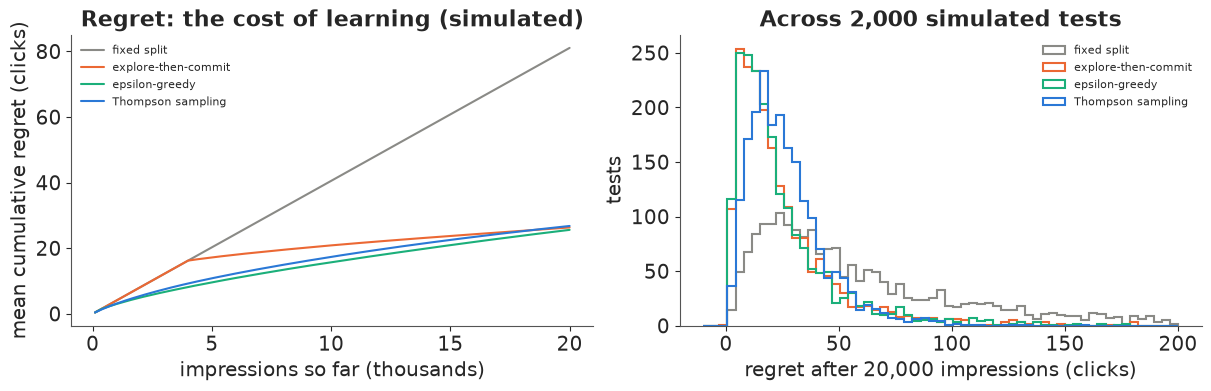

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for pol, col in zip(POLICIES, [GREY, ORANGE, AQUA, BLUE]):
    reg = bandit[pol][0]
    axes[0].plot(t_axis / 1000, reg.mean(axis=0), color=col, label=pol)
axes[0].set(xlabel="impressions so far (thousands)", ylabel="mean cumulative regret (clicks)",
            title="Regret: the cost of learning (simulated)")
axes[0].legend(fontsize=8)
for pol, col in zip(POLICIES, [GREY, ORANGE, AQUA, BLUE]):
    reg = bandit[pol][0][:, -1]
    axes[1].hist(reg, bins=np.linspace(-10, 200, 60), histtype="step", lw=1.5, color=col, label=pol)
axes[1].set(xlabel="regret after 20,000 impressions (clicks)", ylabel="tests",
            title="Across 2,000 simulated tests")
axes[1].legend(fontsize=8);

The fixed split loses, by construction, the whole difference between the best and the average
arm for every impression of the test (81 clicks per 20,000). The three adaptive policies lose
about a third as much, 26-27 clicks, and over 20,000 impressions they are nearly tied.
Thompson sampling needs no tuning constant, has the lightest bad tail (90% of tests below 49
clicks) and ends with the most reliable final choice (the true best arm in 72% of tests, vs 65%
for the others). Its regret curve keeps bending over as it stops exploring, while epsilon-greedy
pays for its 10% exploration forever and explore-then-commit's cost depends on a test length
chosen in advance - which is the next question.

## D2 · The decision: how long should a headline test run?

Upworthy did not run bandits: it tested, then showed the winner to everyone for the rest of the
story's life. The right test length depends on how much traffic comes *after* the test: long
tests waste impressions on bad headlines, short tests pick the wrong one more often and pay for it
on all later traffic. With the fitted population we can compute the expected total regret of
"test $n$ impressions per arm, then commit" for a story that will get $N$ impressions in total
(a **preposterior** analysis: averaged over effects drawn from the population and over the data
a test would produce). We also compute two planning numbers from the same simulation: the
chance the test picks the best arm, and the classical **power** of a two-arm z-test at
$\alpha = 0.05$ for realistic effects.

impressions per arm      : [  100   200   400   700  1000  1500  2000  3000  4000  6000  8000 12000]
P(pick the best arm)     : [0.36 0.38 0.44 0.5  0.54 0.56 0.6  0.63 0.68 0.72 0.73 0.79]
share of possible gain   : [0.43 0.47 0.59 0.69 0.74 0.79 0.82 0.84 0.89 0.92 0.93 0.95]
two-arm power (p < 0.05) : [0.03 0.05 0.08 0.1  0.14 0.15 0.18 0.24 0.27 0.32 0.39 0.44]


,best n per arm,regret at best n,"regret at Upworthy's ~3,000 per arm",regret with no test (random arm),P(pick best) at best n,Thompson sampling throughout
story size N (impressions),,,,,,
"20,000",1000,33.18,53.79,81.08,0.54,26.44
"100,000",2000,100.94,105.26,405.38,0.60,58.56
"500,000",6000,251.54,362.60,2026.88,0.72,105.82


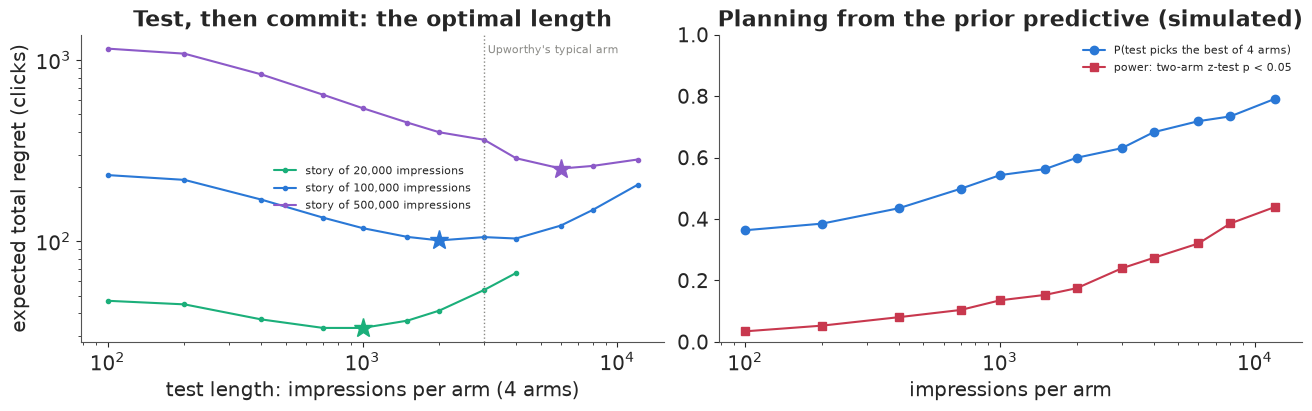

In [26]:
n_grid = np.array([100, 200, 400, 700, 1000, 1500, 2000, 3000, 4000, 6000, 8000, 12_000])
rng_d = np.random.default_rng(51)
mean_gap = (p_best[:, None] - p_b).sum(axis=1)             # regret per round of 1 impression per arm
p_pick_best, gap_after = [], []
for n_ in n_grid:
    yk = rng_d.binomial(n_, p_b)
    choice = np.argmax(yk + rng_d.random(yk.shape) * 1e-3, axis=1)   # random tie-break
    gap_after.append(p_best - p_b[np.arange(S_B), choice])
    p_pick_best.append(np.mean(gap_after[-1] == 0))
gap_after = np.array(gap_after)                             # (n, test)

# two-arm power for realistic effects (arms 0 and 1 of each simulated test)
power = []
for n_ in n_grid:
    ya_, yb_ = rng_d.binomial(n_, p_b[:, 0]), rng_d.binomial(n_, p_b[:, 1])
    pool = (ya_ + yb_) / (2 * n_)
    se = np.sqrt(np.maximum(pool * (1 - pool) * 2 / n_, 1e-12))
    power.append(np.mean(np.abs((yb_ - ya_) / n_) / se > 1.96))


def etc_regret(N):
    """Expected total regret (clicks) of testing n per arm and committing, story of N impressions."""
    test_cost = n_grid * mean_gap.mean()
    after = np.maximum(N - K_B * n_grid, 0) * gap_after.mean(axis=1)
    return np.where(K_B * n_grid <= N, test_cost + after, np.nan)


LIFE = [20_000, 100_000, 500_000]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rows = []
for N_, col in zip(LIFE, [AQUA, BLUE, PURPLE]):
    reg_n = etc_regret(N_)
    i_best = np.nanargmin(reg_n)
    axes[0].plot(n_grid, reg_n, "o-", ms=3, color=col, label=f"story of {N_:,} impressions")
    axes[0].plot(n_grid[i_best], reg_n[i_best], "*", ms=14, color=col)
    ts_reg = run_policy("Thompson sampling", p_b[:500], nb=N_ // 500, batch=500, seed=43)[0][:, -1].mean()
    rows.append({"story size N (impressions)": f"{N_:,}", "best n per arm": n_grid[i_best],
                 "regret at best n": reg_n[i_best],
                 "regret at Upworthy's ~3,000 per arm": reg_n[n_grid == 3000][0],
                 "regret with no test (random arm)": N_ * mean_gap.mean() / K_B,
                 "P(pick best) at best n": p_pick_best[i_best],
                 "Thompson sampling throughout": ts_reg})
axes[0].axvline(3000, color=GREY, ls=":", lw=1)
axes[0].text(3100, axes[0].get_ylim()[1] * 0.9, "Upworthy's typical arm", fontsize=8, color=GREY)
axes[0].set(xscale="log", yscale="log", xlabel="test length: impressions per arm (4 arms)",
            ylabel="expected total regret (clicks)", title="Test, then commit: the optimal length")
axes[0].legend(fontsize=8)
axes[1].plot(n_grid, p_pick_best, "o-", color=BLUE, label="P(test picks the best of 4 arms)")
axes[1].plot(n_grid, power, "s-", color=RED, label="power: two-arm z-test p < 0.05")
axes[1].set(xscale="log", ylim=(0, 1), xlabel="impressions per arm",
            title="Planning from the prior predictive (simulated)")
axes[1].legend(fontsize=8)
gain_kept = 1 - gap_after.mean(axis=1) / (p_best - p_b.mean(axis=1)).mean()
print("impressions per arm      :", n_grid)
print("P(pick the best arm)     :", np.round(p_pick_best, 2))
print("share of possible gain   :", np.round(gain_kept, 2))
print("two-arm power (p < 0.05) :", np.round(power, 2))
pd.DataFrame(rows).set_index("story size N (impressions)").round(2)

The answer depends on how many impressions the story will get, and the dependence is gentle: a
25-fold increase in audience (20,000 to 500,000) moves the optimal test from about 1,000 to
about 6,000 impressions per arm. For a story of 100,000 impressions the optimum is near 2,000 per
arm, and Upworthy's typical ~3,000 costs only about 4 clicks more; for a small story (20,000) the
same 3,000 per arm wastes about 20 clicks, and for a big one (500,000) it stops too early. (We do
not know Upworthy's real audience per story; these sizes are assumptions.)

The planning panel explains why "significance" is the wrong target. For realistic effects the
**power** of a two-arm z-test is low: about 24% at 3,000 impressions per arm. Yet a four-arm test
of that size picks the truly best headline 63% of the time and captures about 84% of the clicks
that a perfect choice would gain, because when it picks the wrong arm the difference is usually
small. The decision problem is not "is there a difference?" but "how many clicks does choosing now
cost?".

Finally, **Thompson sampling over the whole life of the story beats every test length**: 59 vs
101 clicks of regret at 100,000 impressions, and about 106 vs 250 at 500,000, with no test length
to choose at all. If the platform can adapt traffic continuously, it should. (Our simulated
bandit assumes CTRs do not drift over the story's life; with drift, a bandit needs to forget old
data, and a test-then-commit plan is worse still.)

## Summary

* **One test.** P(best) and expected loss answer the editor's question; a p-value answers a
  different one. Expected loss (and its twin, the value of information) is a stopping rule with
  units you can reason about.
* **Real effect sizes.** Across 1,000 Upworthy tests, headline effects are heavy-tailed
  (Student-t, $\nu \approx 3$). A Normal effect model misses the tails; a split-half replication on
  real data shows the raw winner's advantage is about twice its true size, and that the
  hierarchical posterior predicts the replication.
* **Peeking.** "Stop at p < 0.05" inflates false positives several-fold, and so does a
  flat-prior "P(B > A) > 97.5%". With a prior that matches the population, posterior claims stay
  calibrated under optional stopping - a statement about calibration, not about error rates in
  A/A tests.
* **Deciding.** Expected-loss stopping, Thompson sampling, and a preposterior choice of the test
  length all turn the population model into decisions measured in clicks.

## Try it yourself

1. **Mixture of null and real effects.** Replace the Student-t effects by a two-component normal
   mixture (a narrow "no real difference" component and a wide one). What fraction of headline
   variants are essentially identical? Does the split-half replication improve?
2. **Test the claims on held-out data.** The archive has a separate confirmatory sample on OSF
   (`upworthy-archive-confirmatory-packages-03.12.2020.csv`). Use the fitted population as a prior
   for 500 of its tests and compare P(best) with a split-half replication, as in B5.
3. **A better bandit.** Give Thompson sampling the population prior instead of Beta(1, 1) (sample
   arm effects from the posterior under the Student-t prior, e.g. on a grid for each arm's
   log-odds relative to the leader). How much regret does the prior save in the first
   2,000 impressions?